In [2]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

uploaded = files.upload()

Saving Personal_Finance_Dataset.csv to Personal_Finance_Dataset.csv


In [3]:
df = pd.read_csv("Personal_Finance_Dataset.csv")

print(df.shape)
df.head()

(1500, 5)


,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense


In [4]:
df.info()
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     1500 non-null   object 
 1   Transaction Description  1500 non-null   object 
 2   Category                 1500 non-null   object 
 3   Amount                   1500 non-null   float64
 4   Type                     1500 non-null   object 
dtypes: float64(1), object(4)
memory usage: 58.7+ KB
['Date', 'Transaction Description', 'Category', 'Amount', 'Type']


In [5]:
print(df.isnull().sum())
print(df.duplicated().sum())

Date                       0
Transaction Description    0
Category                   0
Amount                     0
Type                       0
dtype: int64
0


In [6]:
df.describe()

,Amount
count,1500.000000
mean,1307.520913
std,982.283361
min,14.370000
25%,629.340000
50%,1156.285000
75%,1712.932500
max,4996.000000


In [7]:
df['Date'] = pd.to_datetime(df['Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     1500 non-null   datetime64[ns]
 1   Transaction Description  1500 non-null   object        
 2   Category                 1500 non-null   object        
 3   Amount                   1500 non-null   float64       
 4   Type                     1500 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 58.7+ KB


In [8]:
print(df['Date'].min())
print(df['Date'].max())

2020-01-02 00:00:00
2024-12-29 00:00:00


In [9]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day
df['Day_Name'] = df['Date'].dt.day_name()

In [10]:
df.head()

,Date,Transaction Description,Category,Amount,Type,Year,Month,Month_Name,Day,Day_Name
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense,2020,1,January,2,Thursday
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense,2020,1,January,2,Thursday
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense,2020,1,January,4,Saturday
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income,2020,1,January,5,Sunday
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense,2020,1,January,13,Monday


In [11]:
print(df['Category'].value_counts())

Category
Rent                165
Travel              160
Utilities           157
Health & Fitness    152
Shopping            150
Food & Drink        149
Salary              146
Entertainment       143
Investment          142
Other               136
Name: count, dtype: int64


In [12]:
print(df['Type'].value_counts())

Type
Expense    1222
Income      278
Name: count, dtype: int64


In [13]:
type_summary = df.groupby('Type')['Amount'].sum()
type_summary

,Amount
Type,
Expense,1227194.37
Income,734087.00


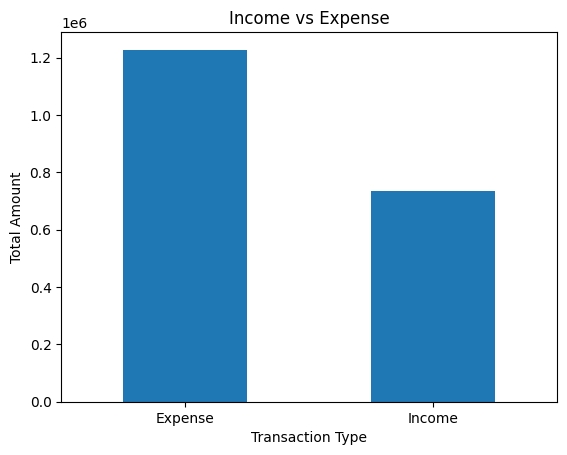

In [14]:
type_summary.plot(kind='bar')
plt.title('Income vs Expense')
plt.xlabel('Transaction Type')
plt.ylabel('Total Amount')
plt.xticks(rotation=0)
plt.show()

In [16]:
expenses = df[df['Type'] == 'Expense']
expenses.head()

,Date,Transaction Description,Category,Amount,Type,Year,Month,Month_Name,Day,Day_Name
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense,2020,1,January,2,Thursday
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense,2020,1,January,2,Thursday
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense,2020,1,January,4,Saturday
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense,2020,1,January,13,Monday
5,2020-01-14,Benefit suggest page southern.,Shopping,448.68,Expense,2020,1,January,14,Tuesday


In [17]:
category_spending = expenses.groupby('Category')['Amount'].sum().sort_values(ascending=False)
category_spending

,Amount
Category,
Travel,169497.79
Rent,162075.39
Food & Drink,159493.39
Salary,149053.55
Entertainment,148165.47
Shopping,146880.75
Utilities,146833.97
Health & Fitness,145194.06


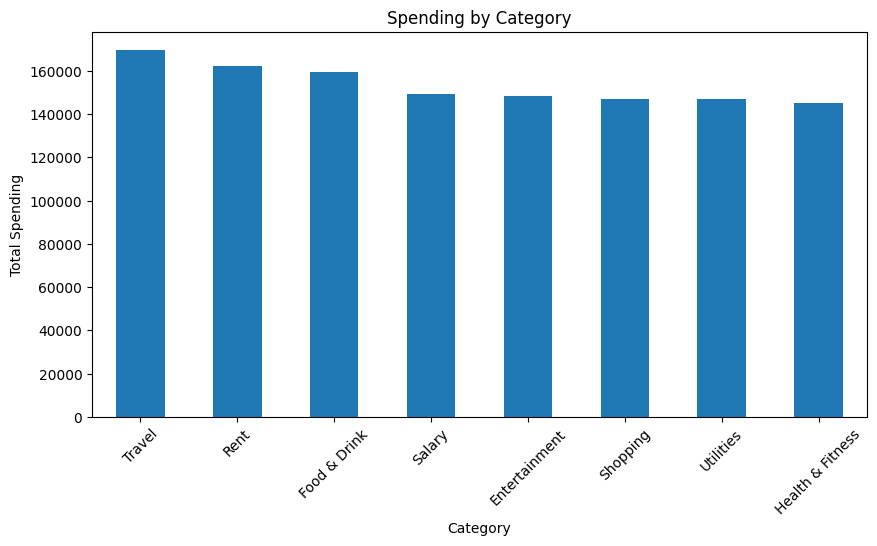

In [18]:
category_spending.plot(kind='bar', figsize=(10, 5))
plt.title('Spending by Category')
plt.xlabel('Category')
plt.ylabel('Total Spending')
plt.xticks(rotation=45)
plt.show()

In [19]:
category_percentage = (category_spending / category_spending.sum() * 100).round(2)
category_percentage

,Amount
Category,
Travel,13.81
Rent,13.21
Food & Drink,13.00
Salary,12.15
Entertainment,12.07
Shopping,11.97
Utilities,11.97
Health & Fitness,11.83


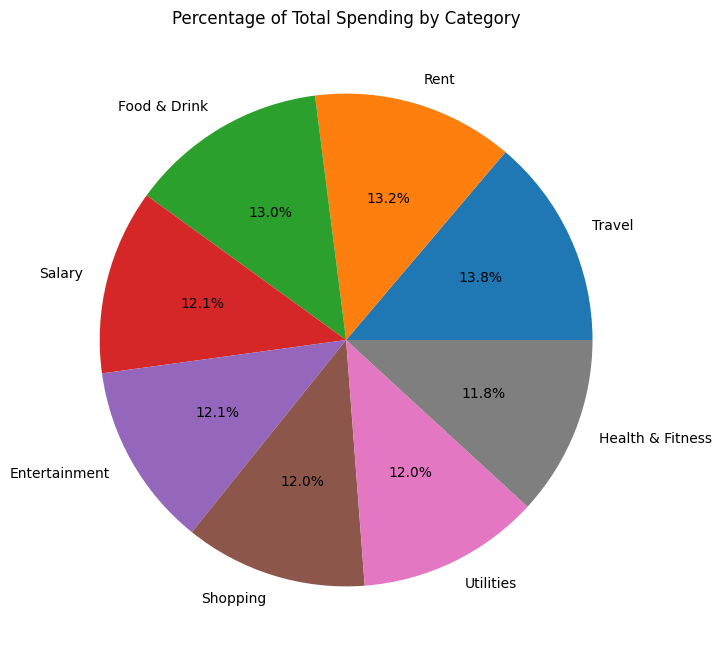

In [20]:
category_percentage.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8))
plt.title('Percentage of Total Spending by Category')
plt.ylabel('')
plt.show()

In [21]:
print('Highest spending category:', category_spending.idxmax())
print('Amount spent:', category_spending.max())

Highest spending category: Travel
Amount spent: 169497.79


In [22]:
monthly_expenses = expenses.groupby(['Year', 'Month'])['Amount'].sum()
monthly_expenses

Year  Month
2020  1        17138.25
      2        17108.41
      3        13581.81
      4        16233.05
      5        16846.13
      6        20680.72
      7        24026.27
      8        31386.80
      9        21515.15
      10       22162.99
      11       26735.16
      12       28358.12
2021  1        15817.11
      2        19925.23
      3        26223.24
      4        23097.71
      5        23780.78
      6        22137.63
      7        19122.37
      8        14574.03
      9        17084.76
      10       12559.57
      11       14325.37
      12        9996.66
2022  1        20832.61
      2        20042.69
      3        27736.19
      4        21445.01
      5        31344.05
      6        25557.78
      7        19190.82
      8        24246.00
      9        18901.86
      10       16412.30
      11       19550.74
      12       11516.30
2023  1        28714.75
      2        16870.03
      3        16720.78
      4        16726.65
      5        18021.87
      6        20070.77
      7        26122.96
      8        17372.59
      9        25849.78
      10       14541.21
      11       22832.52
      12       20654.33
2024  1        29916.13
      2        23807.30
      3        16436.43
      4        15443.17
      5        15822.56
      6        22554.07
      7        27716.08
      8        22933.69
      9        19383.94
      10       22984.21
      11       23565.96
      12       10938.92
Name: Amount, dtype: float64

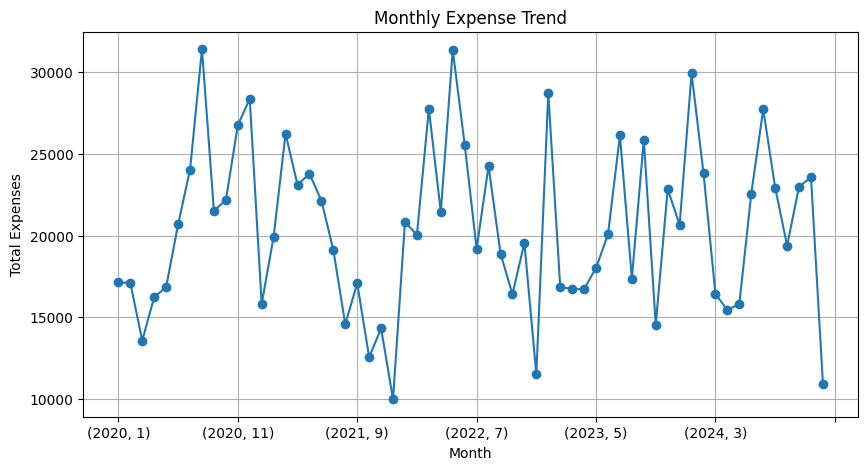

In [23]:
monthly_expenses.plot(kind='line', marker='o', figsize=(10, 5))
plt.title('Monthly Expense Trend')
plt.xlabel('Month')
plt.ylabel('Total Expenses')
plt.grid()
plt.show()

In [24]:
monthly_summary = df.groupby(['Year', 'Month', 'Type'])['Amount'].sum().unstack(fill_value=0)
monthly_summary

Type         Expense   Income
Year Month                   
2020 1      17138.25   5578.0
     2      17108.41  20070.0
     3      13581.81   3465.0
     4      16233.05   7370.0
     5      16846.13   6008.0
     6      20680.72  12346.0
     7      24026.27   6092.0
     8      31386.80  14941.0
     9      21515.15   1385.0
     10     22162.99  12897.0
     11     26735.16   8369.0
     12     28358.12   3745.0
2021 1      15817.11  13564.0
     2      19925.23    804.0
     3      26223.24  30466.0
     4      23097.71   1168.0
     5      23780.78   5283.0
     6      22137.63   5599.0
     7      19122.37  12726.0
     8      14574.03   7445.0
     9      17084.76  16445.0
     10     12559.57  13511.0
     11     14325.37  12905.0
     12      9996.66  30482.0
2022 1      20832.61  10946.0
     2      20042.69  19899.0
     3      27736.19  20747.0
     4      21445.01  10218.0
     5      31344.05  12317.0
     6      25557.78  11304.0
     7      19190.82  11355.0
     8      24246.00  14408.0
     9      18901.86  20023.0
     10     16412.30   7195.0
     11     19550.74   5295.0
     12     11516.30   4019.0
2023 1      28714.75  25952.0
     2      16870.03  17267.0
     3      16720.78  26117.0
     4      16726.65   4306.0
     5      18021.87  20322.0
     6      20070.77   7871.0
     7      26122.96   8101.0
     8      17372.59   8178.0
     9      25849.78   7926.0
     10     14541.21  16717.0
     11     22832.52  14240.0
     12     20654.33   3601.0
2024 1      29916.13  22974.0
     2      23807.30  12637.0
     3      16436.43   6840.0
     4      15443.17  22782.0
     5      15822.56   4296.0
     6      22554.07  13970.0
     7      27716.08  19354.0
     8      22933.69   6655.0
     9      19383.94  19948.0
     10     22984.21  12974.0
     11     23565.96  24139.0
     12     10938.92   6530.0

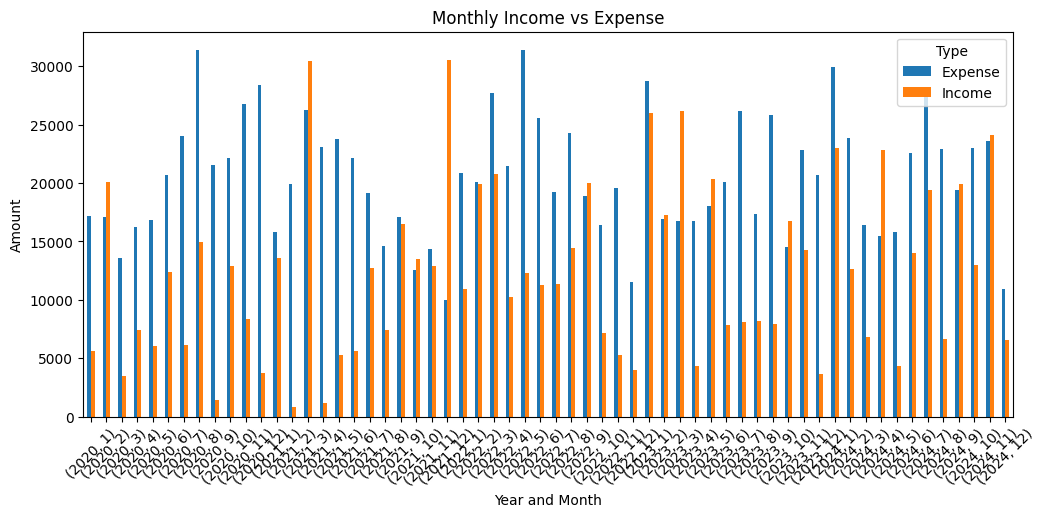

In [25]:
monthly_summary.plot(kind='bar', figsize=(12, 5))
plt.title('Monthly Income vs Expense')
plt.xlabel('Year and Month')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.show()

In [26]:
monthly_income = df[df['Type'] == 'Income'].groupby(['Year', 'Month'])['Amount'].sum()
monthly_expenses = df[df['Type'] == 'Expense'].groupby(['Year', 'Month'])['Amount'].sum()

monthly_savings = monthly_income.subtract(monthly_expenses, fill_value=0)

monthly_savings

Year  Month
2020  1       -11560.25
      2         2961.59
      3       -10116.81
      4        -8863.05
      5       -10838.13
      6        -8334.72
      7       -17934.27
      8       -16445.80
      9       -20130.15
      10       -9265.99
      11      -18366.16
      12      -24613.12
2021  1        -2253.11
      2       -19121.23
      3         4242.76
      4       -21929.71
      5       -18497.78
      6       -16538.63
      7        -6396.37
      8        -7129.03
      9         -639.76
      10         951.43
      11       -1420.37
      12       20485.34
2022  1        -9886.61
      2         -143.69
      3        -6989.19
      4       -11227.01
      5       -19027.05
      6       -14253.78
      7        -7835.82
      8        -9838.00
      9         1121.14
      10       -9217.30
      11      -14255.74
      12       -7497.30
2023  1        -2762.75
      2          396.97
      3         9396.22
      4       -12420.65
      5         2300.13
      6       -12199.77
      7       -18021.96
      8        -9194.59
      9       -17923.78
      10        2175.79
      11       -8592.52
      12      -17053.33
2024  1        -6942.13
      2       -11170.30
      3        -9596.43
      4         7338.83
      5       -11526.56
      6        -8584.07
      7        -8362.08
      8       -16278.69
      9          564.06
      10      -10010.21
      11         573.04
      12       -4408.92
Name: Amount, dtype: float64

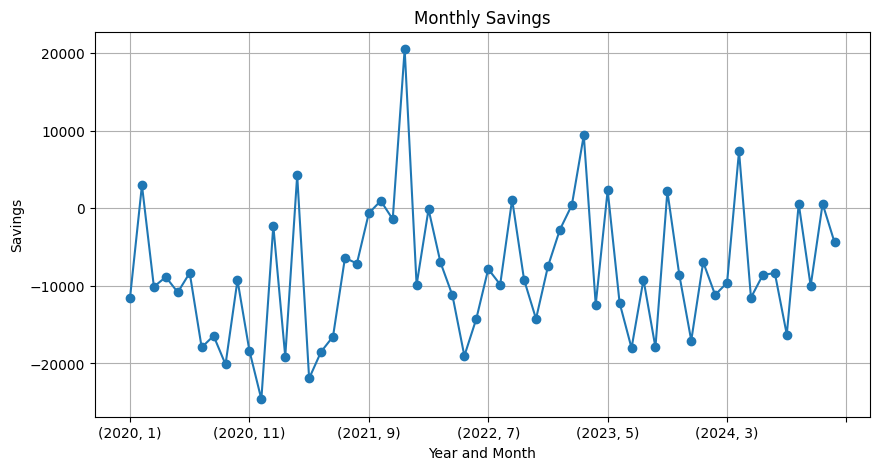

In [27]:
monthly_savings.plot(kind='line', marker='o', figsize=(10, 5))
plt.title('Monthly Savings')
plt.xlabel('Year and Month')
plt.ylabel('Savings')
plt.grid()
plt.show()